In [15]:
# 1. IMPORT LIBRARIES



import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator #data augmentation

In [17]:
imgage_size=(150,150)
batch_size=32

In [18]:
train_datagen=ImageDataGenerator(rescale=1/255,   
                                 shear_range=0.2, #check more option
                                 
                                 )

test_datagen=ImageDataGenerator(rescale=1/255,
                                 shear_range=0.2, #check more option
                                 )

In [19]:
training_set=train_datagen.flow_from_directory('dataset/training_set',
                                               target_size=imgage_size,
                                               batch_size=batch_size,
                                               class_mode='binary')


test_set=train_datagen.flow_from_directory('dataset/test_set',
                                               target_size=imgage_size,
                                               batch_size=batch_size,
                                               class_mode='binary')

Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [ ]:

#build model 
model=keras.Sequential(
    [
        
        keras.layers.Conv2D(32,(3,3), activation='relu',input_shape=(150,150,3)),     
     
        keras.layers.MaxPooling2D((3,3)),     
        keras.layers.Conv2D(32,(3,3), activation='relu'),     
        keras.layers.MaxPooling2D((3,3)),     
        keras.layers.Conv2D(32,(3,3), activation='relu'),     
        keras.layers.Flatten(),     
        keras.layers.Dense(512, activation='relu',),     
        keras.layers.Dense(1, activation='sigmoid'),     
     
     ]
)

c:\Users\Zohaib\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',metrics=['accuracy']


)


history = model.fit(
    training_set,
    epochs=20,
    validation_data=test_set
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 164s 634ms/step - accuracy: 0.6800 - loss: 0.5971 - val_accuracy: 0.7145 - val_loss: 0.5479
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 116s 464ms/step - accuracy: 0.7431 - loss: 0.5106 - val_accuracy: 0.7535 - val_loss: 0.4887
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 117s 466ms/step - accuracy: 0.7937 - loss: 0.4433 - val_accuracy: 0.7810 - val_loss: 0.4752
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 135s 438ms/step - accuracy: 0.8170 - loss: 0.3921 - val_accuracy: 0.7660 - val_loss: 0.5014
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 114s 455ms/step - accuracy: 0.8456 - loss: 0.3408 - val_accuracy: 0.8015 - val_loss: 0.4373
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 116s 464ms/step - accuracy: 0.8784 - loss: 0.2800 - val_accuracy: 0.7870 - val_loss: 0.4730
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 113s 450ms/step - accuracy: 0.9100 - loss: 0.2134 - val_accuracy: 0.7875 - val_loss: 0.5233
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 117s 466ms/step - accuracy: 0.9421 -

In [29]:
test_loss, test_acc = model.evaluate(test_set)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - accuracy: 0.7920 - loss: 0.9640
Test Loss: 0.9640240669250488
Test Accuracy: 0.7919999957084656


In [30]:

y_pred = model.predict(test_set)
import numpy as np

y_pred = np.argmax(y_pred, axis=1)
y_true = test_set.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 235ms/step


In [31]:
y_true

array([0, 0, 0, ..., 1, 1, 1], shape=(2000,), dtype=int32)

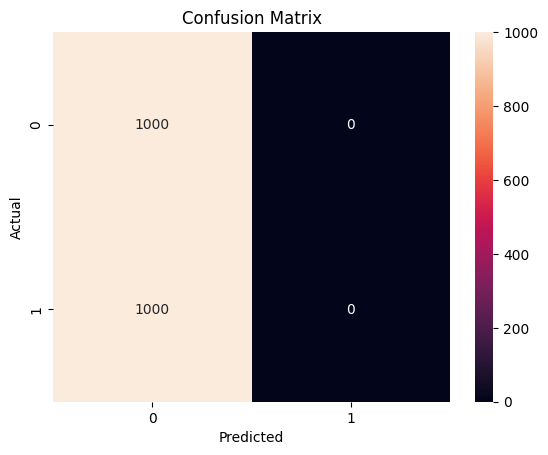

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))





              precision    recall  f1-score   support

           0       0.50      1.00      0.67      1000
           1       0.00      0.00      0.00      1000

    accuracy                           0.50      2000
   macro avg       0.25      0.50      0.33      2000
weighted avg       0.25      0.50      0.33      2000



c:\Users\Zohaib\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Zohaib\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Zohaib\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

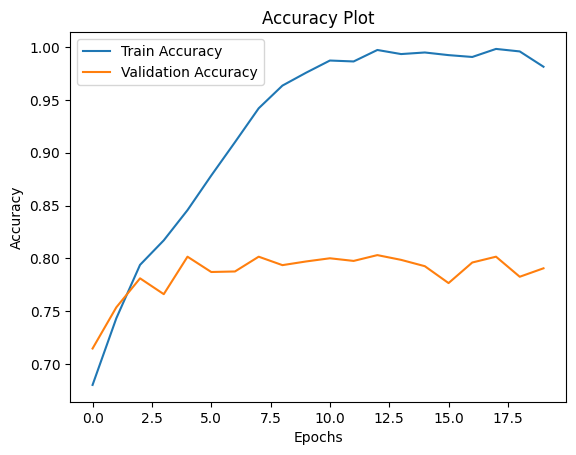

In [34]:
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Plot')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [35]:
model.save_weights('cat_dog.weights.h5')
